# Humanoid Sensors and Actuators
## Group 5
| Name | Matr. # | Email |
|------|---------|-------|
| Samuele Ribaudo | 03821248 | samuele.ribaudo@tum.de |
| Hong Yan Jun  | 03813507 | go75kes@mytum.de |
| Alessandro Canalicchio | 03796273 | go73xix@mytum.de |
| Niklas Peter | 03812287 | n.peter@tum.de |
| Emile Gebrael | 03812968 | emile.gebrael@tum.de |

# Tutorial 5

Course Instructor: Dr.-Ing. J. Rogelio Guadarrama Olvera
hsa-lecture.ics@xcit.tum.de

Summer Semester 2026

## Notebook Setup

1. Open the VS Code terminal.
2. Create the virtual environment: `python -m venv .venv`
3. Activate it:
* **Mac/Linux:** `source .venv/bin/activate`
* **Windows:** `.\.venv\Scripts\activate`
4. Go to code directory `cd T5/code/`
5. Install dependencies: `pip install -r requirements.txt`

6. Set the Notebook Kernel: Click **Select Kernel** in the top right -> **Python Environments** -> Choose **.venv**.

Run the following code block to import all the required libraries. 

In [62]:
import numpy as np
import matplotlib.pyplot as plt

## Acoustic Sensors and Signal Processing (57 points)

In this tutorial we will refresh some basics of signal processing including correlation, Fast Fourier Transform (FFT) and filtering. All tasks are solvable with Python, Matlab, Octave or Scilab with a slightly varying syntax.

**Note:** You may use any of the above programming languages. However, we strongly recommend using Jupyter Notebooks (python) to solve and visualize all the tutorial. We will only support installation/setup questions related to python.

## 1 Sound Source Localization (8 points)

### Report

**R.1.1 (3 points)** Find the expression to determine the azimuth angle of a sound source for a system with two microphones. Derive the equations shown in the slides of Lecture 3 step by step.

1. Calculate the path length difference using the speed of sound $c$ and the time delay $\Delta t$:
$$\text{Distance}=c\Delta t$$

2. Determine the geometric extra distance the sound travels to the further microphone using trigonometry:
$$\text{Distance}=l\sin\theta$$

3. Equate the two expressions representing the same distance:
$$l\sin\theta=c\Delta t$$

4. Divide both sides by $l$ to isolate the angle expression:
$$\sin\theta=\frac{c\Delta t}{l}$$



**R.1.2 (3 points)** Find the expression to determine the velocity of a target from the pulse duration difference of a radar sensor. Derive the equations shown in the slides of Lecture 3 step by step.




1. Start with the base formula for the Doppler frequency shift $\Delta f$ given the emitted frequency $f_0$:
$$\Delta f=\frac{2\Delta v}{c}f_0$$

2. Multiply both sides by the wave propagation speed $c$:
$$c\Delta f=2\Delta vf_0$$

3. Divide both sides by $2f_0$ to isolate the velocity variable $\Delta v$:
$$\Delta v=\frac{c\Delta f}{2f_0}$$



**R.1.3 (1 point)** How can we measure the distance to a target?




We can measure distance using the time-of-flight principle by calculating the time delay between an emitted singal and its returning echo.



**R.1.4 (1 point)** How can we measure the speed of a moving target?




We can measure the speed of a moving target by using the Doppler effect to analyze the frequency shift between an emitted wave and its returning echo.



## 2 Fast Fourier Transform (8 points)

### Tasks

**T.2.1** Create a signal consisting of the sum of two sine waves using a sample frequency of 1000Hz, one with amplitude of 1 and frequency of 50 Hz and the other with amplitude 0.5 and frequency 120 Hz. Plot the signal over a time slot of 2s.




In [63]:
# type here the code...



**T.2.2** Run a FFT (Fast Fourier transform) on the signal from T.2.1 and plot it. Normalize the output to 1 and only show positive frequencies.




In [64]:
# type here the code...



**T.2.3** Add random noise to the signal from T.2.1 and plot the signal again.




In [65]:
# type here the code...



**T.2.4** Run the FFT on the noisy signal from T.2.3 and plot it.




In [66]:
# type here the code...



### Report

**R2.1 (2 points)** Is it possible to implement FFT to an online data streaming? Why?




Type here the answer...




**R2.2 (2 points)** How can you use FFT in signal processing?




Type here the answer...




**R2.3 (2 points)** Deliver the code used to generate the signals and plots?




Type here the code...





## 3 Audio Correlation (8 points)

### Tasks

**T.3.1** Load the ‘chimes.wav’ file into the workspace and isolate one of its channels.

- Plot the signal with a reasonable time scale.
- If you have speakers/headphones: try to output the audio signal.




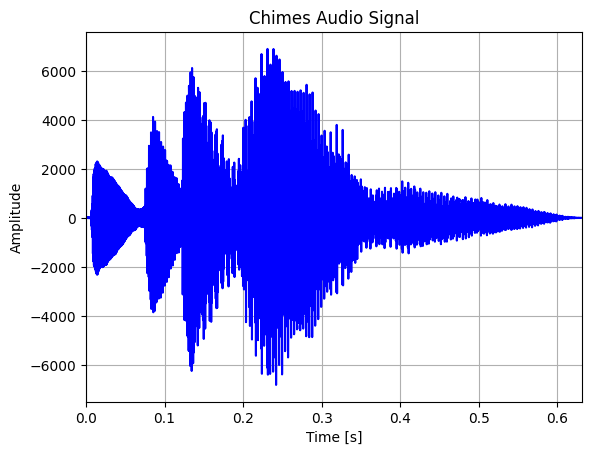

In [67]:
### IMPORT THE AUDIO FILE ###
from scipy.io import wavfile

# Load the audio file
sample_rate, data = wavfile.read('../audio/chimes.wav')

# Isolate one channel
if len(data.shape) > 1:
    signal = data[:, 0] # Left channel
else:
    signal = data       # Already mono

### PLOT THE AUDIO SIGNAL ###
time = np.arange(len(signal)) / sample_rate

plt.plot(time, signal, color='b')
plt.title('Chimes Audio Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, time[-1])  # Limits the x-axis to the exact length of the audio
plt.show()


**T.3.2** Run an FFT on the audio signal from T.3.1 and plot it.




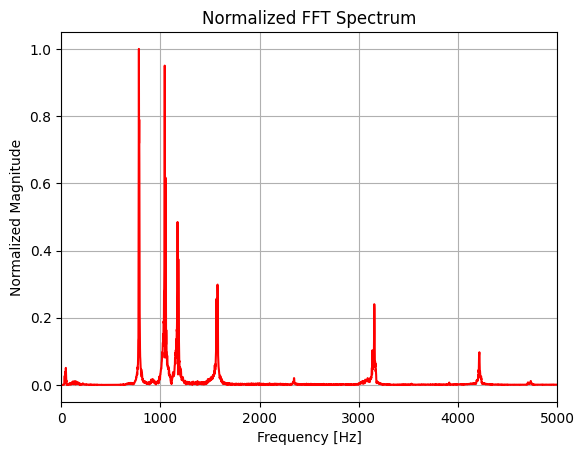

In [68]:
### RUN THE FFT ###
n = len(signal)

fft_output = np.fft.fft(signal)

frequencies = np.fft.fftfreq(n, 1 / sample_rate) # Calculate the frequencies corresponding to the FFT points
magnitude = np.abs(fft_output) # Take the absolute value to get the magnitude spectrum
magnitude_normalized = magnitude / np.max(magnitude) # Normalize the output to 1
# Filter out only the positive frequencies
positive_frequencies = frequencies[:n // 2]
positive_magnitude = magnitude_normalized[:n // 2]

### PLOT THE FFT SPECTRUM ###
plt.plot(positive_frequencies, positive_magnitude, color='r')
plt.title('Normalized FFT Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Normalized Magnitude')
plt.grid(True)
plt.xlim(0, 5000)  # Zoomed into 0-5kHz where most audio frequencies lie
plt.show()


**T.3.3** Generate a left and a right channel from the signal of T.3.1 and add a delay and scaling factor to one of them. Make the delay and scaling factors variable.




In [69]:
delay = 0.01  # seconds
scaling_factor = 0.7

# Convert the time delay into the number of discrete samples
delay_samples = int(delay * sample_rate)

# Left channel: Pad with zeros at the end
left_channel = np.pad(signal, (0, delay_samples), mode='constant')
# Right channel: Pad with zeros at the start
right_channel = np.pad(signal, (delay_samples, 0), mode='constant') * scaling_factor



**T.3.4** Plot the two signals in the same figure.




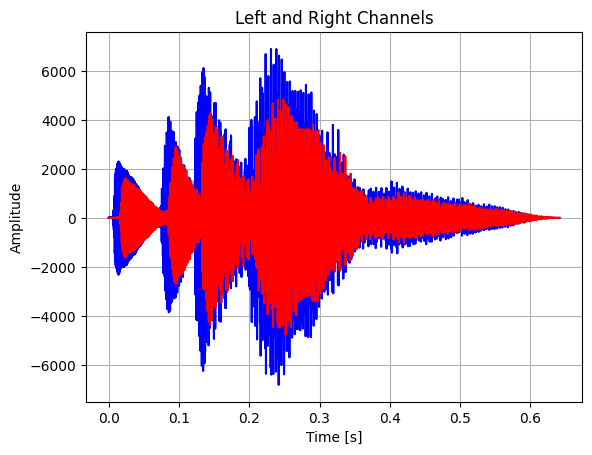

In [70]:
time_padded = np.arange(len(left_channel)) / sample_rate

# Plot both signals together
plt.plot(time_padded, left_channel, label='Left Channel', color='b')
plt.plot(time_padded, right_channel, label='Right Channel', color='r')

plt.title('Left and Right Channels')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

**T.3.5** If you have speakers/headphones: listen to the signals and find parameters at which stereo localization works for you.




In [71]:
# Stack channels vertically to create a stereo layout (2, N) and transpose to (N, 2)
stereo_signal = np.vstack((left_channel, right_channel)).T

# Ensure the data type is correct for audio playback (16-bit PCM integer)
if stereo_signal.dtype != np.int16:
    stereo_signal = (stereo_signal / np.max(np.abs(stereo_signal)) * 32767).astype(np.int16)

# Save the file into the audio directory with the delay value in the name
filename = f'../audio/chimes_stereo_{delay}.wav'
wavfile.write(filename, sample_rate, stereo_signal)



**T.3.6** Run cross-correlation on both signals and plot the correlation against delay.




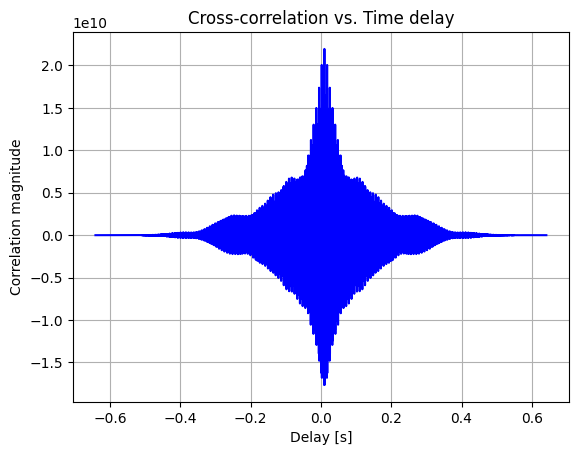

True physical delay configured: 0.01 seconds
Delay estimated by cross-correlation peak: 0.009977324263038548 seconds


In [72]:
cross_corr = np.correlate(right_channel, left_channel, mode='full')

num_lags = len(cross_corr)
lags_samples = np.arange(-num_lags // 2 + 1, num_lags // 2 + 1)

lags_seconds = lags_samples / sample_rate # Convert sample lags into time delays (seconds)

plt.plot(lags_seconds, cross_corr, color='b')
plt.title('Cross-correlation vs. Time delay')
plt.xlabel('Delay [s]')
plt.ylabel('Correlation magnitude')
plt.grid(True)
plt.show()

# Find and print the peak location
estimated_delay = lags_seconds[np.argmax(cross_corr)]
print(f"True physical delay configured: {delay} seconds")
print(f"Delay estimated by cross-correlation peak: {estimated_delay} seconds")


**T.3.7** Add noise with a normal distribution to both channels.




In [73]:
noise_level = 1000.0  

left_noise = np.random.normal(0, noise_level, size=left_channel.shape)
right_noise = np.random.normal(0, noise_level, size=right_channel.shape)

left_channel_noisy = left_channel + left_noise
right_channel_noisy = right_channel + right_noise



**T.3.8** Run cross-correlation on the noisy signals and plot.




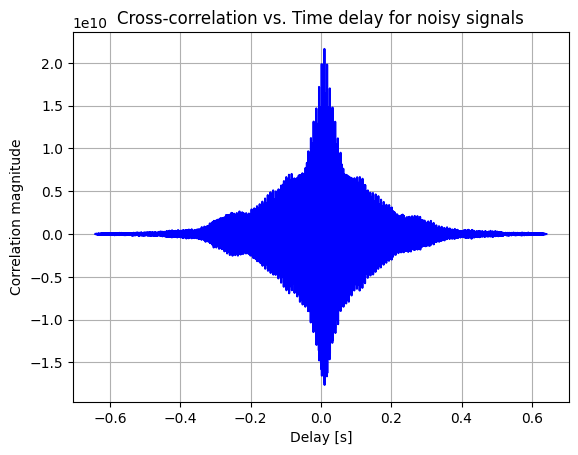

True physical delay configured: 0.01 seconds
Delay estimated by noisy cross-correlation peak: 0.009977324263038548 seconds


In [74]:
cross_corr_noisy = np.correlate(right_channel_noisy, left_channel_noisy, mode='full')

num_lags_noisy = len(cross_corr_noisy)
lags_samples_noisy = np.arange(-num_lags_noisy // 2 + 1, num_lags_noisy // 2 + 1)

lags_seconds_noisy = lags_samples_noisy / sample_rate # Convert sample lags into time delays (seconds)

plt.plot(lags_seconds_noisy, cross_corr_noisy, color='b')
plt.title('Cross-correlation vs. Time delay for noisy signals')
plt.xlabel('Delay [s]')
plt.ylabel('Correlation magnitude')
plt.grid(True)
plt.show()

# Find and print the peak location
estimated_delay_noisy = lags_seconds_noisy[np.argmax(cross_corr_noisy)]
print(f"True physical delay configured: {delay} seconds")
print(f"Delay estimated by noisy cross-correlation peak: {estimated_delay_noisy} seconds")

### Report

**R.3.1 (2 point)** Is it possible to implement the cross-correlation to an online data streaming? Why?




No. An online data stream runs forever. If we try to run a standard cross-correlation on it continuously, the size of our data arrays grows infinitely, becoming a computationally challenging problem.



**R.3.2 (2 point)** If you answered “no” to R.3.1, how would you work around to use it to identify the interaural time delay?




A work around would be to use a sliding window approach: first we divide the continuous incoming audio stream into small buffers of fixed size, then we run the cross correlation only on these slices of data.



**R.3.3 (4 points)** Deliver the code to generate the signals and the plots (T.3.1 - T.3.8).






## 4 Signal Filtering (33 points)

### Tasks

**T.4.1** Create a signal consisting of two sine waves, one with amplitude of 1 and a frequency of 50 Hz and one with amplitude 0.5 and frequency of 500 Hz using a sample frequency of 10,000 Hz.




In [3]:
# type here the code...
import numpy as np
import matplotlib.pyplot as plt

# Signal 1
frequency_1 = 50
amplitude_1 = 1.0

# Signal 2
frequency_2 = 500
amplitude_2 = 0.5

phase = 0              
sampling_rate = 10000
duration = 0.1         

# Time samples
t = np.arange(0, duration, 1 / sampling_rate)

# Sine wave samples (signal 1 + signal 2)
x = amplitude_1 * np.sin(2 * np.pi * frequency_1 * t + phase) + amplitude_2 * np.sin(2 * np.pi * frequency_2 * t + phase)




**T.4.2** Plot the signal over a time slot of 0.1s.




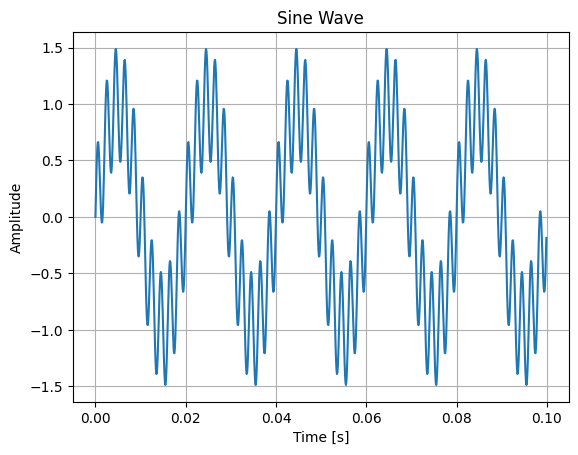

In [4]:

plt.plot(t, x)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Sine Wave")
plt.grid(True)
plt.show()



**T.4.3** Design an analog low-pass passive filter with a cut-off frequency of 50 Hz.

Cut-off frequency:  f_cutoff = 50Hz = 1 / 2*pi*RC -> RC = 1 / 2*pi*50 ≈ 0.00318

Choose for example: R=10kΩ; C=330nF (The ideal Capacitor would ahve 318nF, but this is not commercially available as a part)

Then: f_cutoff = 1 / (2*pi*10000*330*10⁻⁹) ≈ 48.2Hz

So a valid practical design is: R=10kΩ; C=330nF



**T.4.4** Design and implement a first order discrete low-pass filter with cut-off frequency of 50 Hz.




In [5]:
frequency_cutoff_lp = 50
t_s = 1 / sampling_rate
time_constant = 1 / (2*np.pi*frequency_cutoff_lp)

#Filter coefficient
alpha = t_s / (time_constant + t_s)
print(alpha)

# The calculated alpha is then used in the recursive low-pass filter equation:
# y[n] = alpha*x[n] + (1-alpha)*y[n-1]

0.030459027951421226




**T.4.5** Apply the filter from T.4.4 to the signal created in T.4.1. Plot again the signal after filtering.




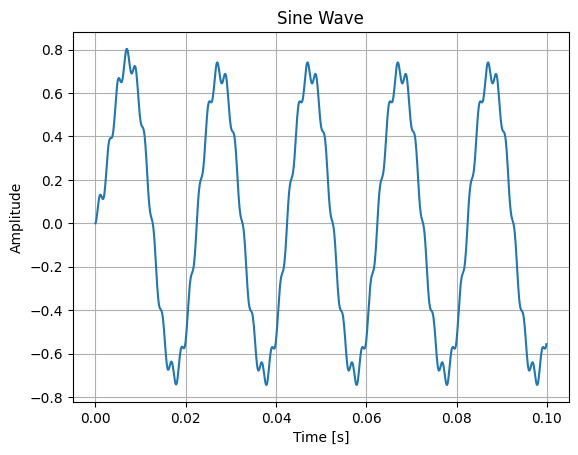

In [6]:
#Initialize
y = np.zeros_like(x)
y[0] = x[0]

#Apply filter
for n in range(1, len(x)):
    y[n] = alpha * x[n] + (1 - alpha) * y[n - 1]

plt.plot(t, y)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Sine Wave")
plt.grid(True)
plt.show()



**T.4.6** Design an analog high-pass passive filter with a cut-off frequency of 500 Hz.




Cut-off frequency:  f_cutoff = 500Hz = 1 / 2*pi*RC -> RC = 1 / 2*pi*500 ≈ 0.000318

Choose for example: R=10kΩ; C=33nF (The ideal Capacitor would have 31.8nF, but this is not commercially available as a part)

Then: f_cutoff = 1 / (2*pi*10000*33*10⁻⁹) ≈ 482Hz

So a valid practical design is: R=10kΩ; C=33nF



**T.4.7** Design and implement a first order discrete high-pass filter with cut-off frequency of 500 Hz.




In [7]:
frequency_cutoff_hp = 500
t_s = 1 / sampling_rate
time_constant = 1 / (2*np.pi*frequency_cutoff_hp)

# Filter coefficient
alpha = time_constant / (time_constant + t_s)
print(alpha)

# The calculated alpha is then used in the recursive high-pass filter equation:
# y[n] = alpha*(y[n-1] + x[n] - x[n-1])

0.7609427763893117




**T.4.8** Apply the filter from T.4.7 to the signal created in T.4.1. Plot again the signal after filtering.




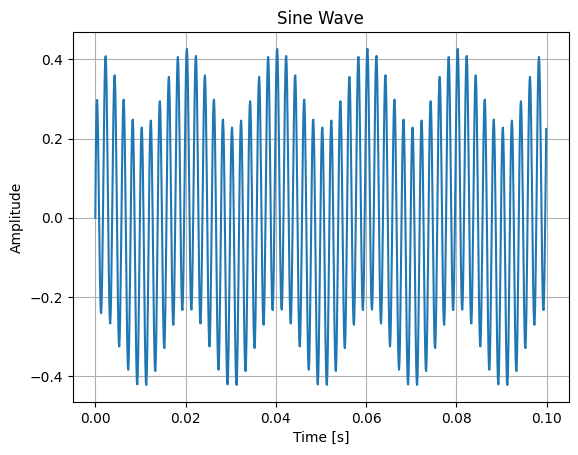

In [8]:
#Initialize
y = np.zeros_like(x)
y[0] = x[0]

#Apply filter
for n in range(1, len(x)):
    y[n] = alpha*(y[n-1] + x[n] - x[n-1])

plt.plot(t, y)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Sine Wave")
plt.grid(True)
plt.show()

**T.4.9** Create another sine wave signal with a frequency of 1,000 Hz using a sample frequency of 10,000 Hz. Then, add it to the signal created in T.4.1.




In [9]:
frequency_3 = 1000
amplitude_3 = 1

x_new = x + amplitude_3* np.sin(2 * np.pi * frequency_3 * t + phase)




**T.4.10** Design an analog band-pass active filter to recover the 500 Hz signal.




Cut-off frequencies: f_low = 400Hz; f_high = 600Hz

f_low = 400Hz = 1 / 2*pi*R1*C1 -> R1C1 = 1 / 2*pi*400 ≈ 0.000398

Choose for example: R1=10kΩ; C1=39nF
Then: f_low = 1 / (2*pi*10000*39*10⁻⁹) ≈ 408Hz

f_high = 600Hz = 1 / 2*pi*R2*C2 -> R2C2 = 1 / 2*pi*600 ≈ 0.000265

Choose for example: R2=10kΩ; C2=27nF
Then: f_high = 1 / (2*pi*10000*27*10⁻⁹) ≈ 589Hz

So a valid practical band pass design is: R1=10kΩ; C1=39nF and R2=10kΩ; C2=27nF

This gives a pass band of approximately 408Hz to 589Hz, so the 500Hz signal passes.



**T.4.11** Design and implement a discrete band-pass filter to recover the 500 Hz signal from the superposed signal.




In [10]:
frequency_cutoff_bph = 400   # lower cut-off frequency
frequency_cutoff_bpl = 600   # upper cut-off frequency

t_s = 1 / sampling_rate

time_constant_bph = 1 / (2*np.pi*frequency_cutoff_bph)
time_constant_bpl = 1 / (2*np.pi*frequency_cutoff_bpl)

# Filter coefficients
alpha_bph = time_constant_bph / (time_constant_bph + t_s)
alpha_bpl = t_s / (time_constant_bpl + t_s)

print(alpha_bph)
print(alpha_bpl)

# The calculated alpha_hp is then used in the recursive high-pass filter equation:
# y_hp[n] = alpha_hp*(y_hp[n-1] + x[n] - x[n-1])

# The calculated alpha_lp is then used in the recursive low-pass filter equation:
# y_bp[n] = y_bp[n-1] + alpha_lp*(y_hp[n] - y_bp[n-1])

0.7991513573351632
0.2737789034256051




**T.4.12** Apply the filter from T.4.11 to the signal created in T.4.9. Plot again the signal after filtering.




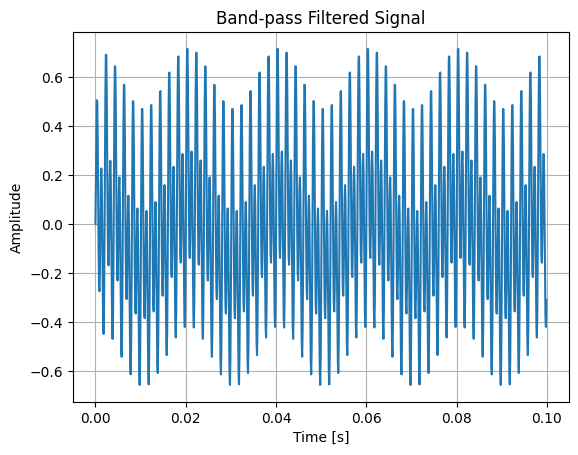

In [83]:
# Initialize
y_hp = np.zeros_like(x_new)
y = np.zeros_like(x_new)    

y_hp[0] = x_new[0]
y[0] = y_hp[0]

# Apply band-pass filter
for n in range(1, len(x_new)):
    # High-pass part
    y_hp[n] = alpha_bph*(y_hp[n-1] + x_new[n] - x_new[n-1])
    # Low-pass part
    y[n] = y[n-1] + alpha_bpl*(y_hp[n] - y[n-1])

plt.plot(t, y)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Band-pass Filtered Signal")
plt.grid(True)
plt.show()


### Report

**R.4.1 (2 points)** Detail the design process of the filter in T.4.3. Draw the required circuit and calculate the value for the components step by step.




The circuit consists of a resistor in series with the input signal and a capacitor connected from the output node to ground. The output voltage is measured across the capacitor.

Circuit:

**!TODO: Image Lowpass filter**

For a passive first-order RC low-pass filter, the cut-off frequency is given by:

$$
f_{cutoff} = \frac{1}{2\pi RC} = 50Hz
$$

Rearranging the equation gives:

$$
RC = \frac{1}{2\pi \cdot 50} \approx 0.00318
$$

A standard resistor value is chosen as:

$$
R = 10k\Omega
$$

Then the ideal capacitor value is:

$$
C = \frac{0.00318}{10000} \approx 318nF
$$

Since 318nF is not a standard capacitor value, a commercially available value of 330nF is selected.

So the chosen component values are:

$$
R = 10k\Omega, C = 330nF
$$

The actual cut-off frequency with these values is:

$$
f_{cutoff} = \frac{1}{2\pi \cdot 10000 \cdot 330 \cdot 10^{-9}} \approx 48.2Hz
$$

This is close to the desired cut-off frequency of 50Hz.

**R.4.2 (2 points)** Detail the design process of the filter in T.4.4. Derive the equation to implement the filter step by step on a data stream.




The digital low-pass filter is based on the same idea as the analog RC low-pass filter, but it is applied to the sampled signal.

The cut-off frequency is set to:

$$
f_{cutoff} = 50Hz
$$

The time constant is calculated with:

$$
\tau = \frac{1}{2\pi f_{cutoff}} = \frac{1}{2\pi \cdot 50} \approx 0.00318s
$$

The sampling time is:

$$
t_s = \frac{1}{sampling\_rate}
$$

With a sampling rate of 10000Hz:

$$
t_s = \frac{1}{10000} = 0.0001s
$$

The filter coefficient is then:

$$
\alpha = \frac{t_s}{\tau + t_s} = \frac{0.0001}{0.00318 + 0.0001} \approx 0.0305
$$

This alpha value is used in the recursive low-pass equation:

$$
y[n] = \alpha x[n] + (1-\alpha)y[n-1]
$$




**R.4.3 (2 points)** Detail the design process of the filter in T.4.6. Draw the required circuit and calculate the value for the components step by step.




The circuit consists of a capacitor in series with the input signal and a resistor connected from the output node to ground. The output voltage is measured across the resistor.

Circuit:

**!TODO: Image Highpass filter**

For a passive first-order RC high-pass filter, the cut-off frequency is given by:

$$
f_{cutoff} = \frac{1}{2\pi RC} = 500Hz
$$

Rearranging the equation gives:

$$
RC = \frac{1}{2\pi \cdot 500} \approx 0.000318
$$

A standard resistor value is chosen as:

$$
R = 10k\Omega
$$

Then the ideal capacitor value is:

$$
C = \frac{0.000318}{10000} \approx 31.8nF
$$

Since 31.8nF is not a standard capacitor value, a commercially available value of 33nF is selected.

So the chosen component values are:

$$
R = 10k\Omega, C = 33nF
$$

The actual cut-off frequency with these values is:

$$
f_{cutoff} = \frac{1}{2\pi \cdot 10000 \cdot 33 \cdot 10^{-9}} \approx 482Hz
$$

This is close to the desired cut-off frequency of 500Hz.

**R.4.4 (2 points)** Detail the design process of the filter in T.4.7. Derive the equation to implement the filter step by step on a data stream.




The digital high-pass filter is based on the same idea as the analog RC high-pass filter, but it is applied to the sampled signal.

The cut-off frequency is set to:

$$
f_{cutoff} = 500Hz
$$

The time constant is calculated with:

$$
\tau = \frac{1}{2\pi f_{cutoff}} = \frac{1}{2\pi \cdot 500} \approx 0.000318s
$$

The sampling time is:

$$
t_s = \frac{1}{sampling\_rate} = \frac{1}{10000} = 0.0001s
$$

The filter coefficient is then:

$$
\alpha = \frac{\tau}{\tau + t_s} = \frac{0.000318}{0.000318 + 0.0001} \approx 0.761
$$

This alpha value is used in the recursive high-pass equation:

$$
y[n] = \alpha \cdot (y[n-1] + x[n] - x[n-1])
$$



**R.4.5 (2 points)** Detail the design process of the filter in T.4.10. Draw the required circuit and calculate the value for the components step by step.




The band-pass filter is made by combining a high-pass filter and a low-pass filter. The high-pass part removes frequencies below the lower cut-off frequency and the low-pass part removes frequencies above the upper cut-off frequency.

Circuit:

**!TODO: Image Bandpass filter**

The lower cut-off frequency is set to:

$$
f_{low} = 400Hz
$$

The upper cut-off frequency is set to:

$$
f_{high} = 600Hz
$$

For the high-pass part, the cut-off frequency is given by:

$$
f_{low} = \frac{1}{2\pi R_1 C_1}
$$

Rearranging the equation gives:

$$
R_1C_1 = \frac{1}{2\pi \cdot 400} \approx 0.000398
$$

A standard resistor value is chosen as:

$$
R_1 = 10k\Omega
$$

Then the ideal capacitor value is:

$$
C_1 = \frac{0.000398}{10000} \approx 39.8nF
$$

A commercially available value of 39nF is selected.

So the chosen values for the high-pass part are:

$$
R_1 = 10k\Omega, C_1 = 39nF
$$

The actual lower cut-off frequency is:

$$
f_{low} = \frac{1}{2\pi \cdot 10000 \cdot 39 \cdot 10^{-9}} \approx 408Hz
$$

For the low-pass part, the cut-off frequency is given by:

$$
f_{high} = \frac{1}{2\pi R_2 C_2}
$$

Rearranging the equation gives:

$$
R_2C_2 = \frac{1}{2\pi \cdot 600} \approx 0.000265
$$

A standard resistor value is chosen as:

$$
R_2 = 10k\Omega
$$

Then the ideal capacitor value is:

$$
C_2 = \frac{0.000265}{10000} \approx 26.5nF
$$

A commercially available value of 27nF is selected.

So the chosen values for the low-pass part are:

$$
R_2 = 10k\Omega, C_2 = 27nF
$$

The actual upper cut-off frequency is:

$$
f_{high} = \frac{1}{2\pi \cdot 10000 \cdot 27 \cdot 10^{-9}} \approx 589Hz
$$

So the practical band-pass filter has approximately these cut-off frequencies:

$$
f_{low} \approx 408Hz, f_{high} \approx 589Hz
$$


**R.4.6 (2 points)** Detail the design process of the filter in T.4.11. Derive the equation to implement the filter step by step on a data stream.




The digital band-pass filter is made by combining a digital high-pass filter and a digital low-pass filter.

The lower cut-off frequency is set to:

$$
f_{low} = 400Hz
$$

The upper cut-off frequency is set to:

$$
f_{high} = 600Hz
$$

The sampling time is:

$$
t_s = \frac{1}{sampling\_rate} = \frac{1}{10000} = 0.0001s
$$

For the high-pass part, the time constant is:

$$
\tau_{hp} = \frac{1}{2\pi f_{low}} = \frac{1}{2\pi \cdot 400} \approx 0.000398s
$$

The high-pass coefficient is:

$$
\alpha_{hp} = \frac{\tau_{hp}}{\tau_{hp} + t_s} = \frac{0.000398}{0.000398 + 0.0001} \approx 0.799
$$

This coefficient is used in the recursive high-pass equation:

$$
y_{hp}[n] = \alpha_{hp} \cdot (y_{hp}[n-1] + x[n] - x[n-1])
$$

For the low-pass part, the time constant is:

$$
\tau_{lp} = \frac{1}{2\pi f_{high}} = \frac{1}{2\pi \cdot 600} \approx 0.000265s
$$

The low-pass coefficient is:

$$
\alpha_{lp} = \frac{t_s}{\tau_{lp} + t_s} = \frac{0.0001}{0.000265 + 0.0001} \approx 0.274
$$

This coefficient is used in the recursive low-pass equation:

$$
y_{bp}[n] = y_{bp}[n-1] + \alpha_{lp} \cdot (y_{hp}[n] - y_{bp}[n-1])
$$

The complete band-pass filter is therefore:

$$
y_{hp}[n] = \alpha_{hp} \cdot (y_{hp}[n-1] + x[n] - x[n-1])
$$

$$
y_{bp}[n] = y_{bp}[n-1] + \alpha_{lp} \cdot (y_{hp}[n] - y_{bp}[n-1])
$$


The output of the high pass is used as the input for the low pass.



**R.4.7 (2 point)** What is the difference between passive and active filters?




Type here the answer...




**R.4.8 (2 point)** What is the difference between FIR and IIR filters?




Type here the answer...




**R.4.9 (2 point)** What is the “order” of a discrete filter?




Type here the answer...




**R.4.10 (2 point)** How could you implement a continuous-time filter in a robotic system?




Type here the answer...




**R.4.11 (2 point)** How could you implement a discrete-time filter in a robotic system?




Type here the answer...




**R.4.12 (3 point)** What are the advantages and disadvantages of analog and digital filters in robotic systems?




Type here the answer...




**R.4.13 (2 point)** Is it possible to make a 1000 Hz Low-Pass filter in a digital system with a sampling rate of 1000 Hz?




Type here the answer...




**R.4.14 (6 points)** Deliver the code to generate the signals and the plots (T.4.1 - T.4.12).


